In [1]:
#Import packages
import numpy as np
import json, copy
import hasasia.sensitivity as hsen
import hasasia.skymap as hsky
import hasasia.utils as hutils
import hasasia.sim as hsim
import holodeck as holo
import matplotlib.pyplot as plt
from astropy import units as utils
from astropy import constants as c
from astropy.coordinates import SkyCoord
import healpy as hp
import matplotlib.cm as cm
#from la_forge.utils import set_publication_params
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import holodeck as holo
from holodeck.constants import GYR, MSOL, PC, YR

import scipy.linalg as sl
import discovery as ds


# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

In [2]:
#!/usr/bin/env python

from __future__ import division
import matplotlib
import matplotlib.pyplot as plt

import numpy as np, pickle
import math, sys, os, glob, json
from astropy import units as u
from sklearn.neighbors import KernelDensity

import pint
from pint import toa
from pint import models
from pint.residuals import Residuals
from pint.simulation import make_fake_toas_fromMJDs
pint.logging.setup(sink=sys.stderr, level="ERROR", usecolors=True)

import pta_replicator
from pta_replicator import simulate
from pta_replicator import white_noise
from pta_replicator import red_noise

from enterprise.pulsar import Pulsar as ePsr


libstempo not installed. PINT or libstempo are required to use par and tim files.


In [3]:
#getting functions from the original bridge sim making script: https://gitlab.nanograv.org/nano-dwg/ng20bridgesims/-/blob/main/NG20v1p1SimData/codes/make_NG20_v1p1_sims.py?ref_type=heads

In [4]:
def make_residual_plot(psr, save=False, simdir='pint_sims1/'):

    # switch to rainbow colormap grouped by telescopes
    colors = {
                "CHIME": "#FFA733",
                "327_ASP": "#BE0119",
                "327_PUPPI": "#BE0119",
                "430_ASP": "#FD9927",
                "430_PUPPI": "#FD9927",
                "L-wide_ASP": "#BDB6F6",
                "L-wide_PUPPI": "#BDB6F6",
                "Rcvr1_2_GASP": "#79A3E2",
                "Rcvr1_2_GUPPI": "#79A3E2",
                "Rcvr1_2_VEGAS": "#79A3E2",
                "Rcvr_800_GASP": "#8DD883",
                "Rcvr_800_GUPPI": "#8DD883",
                "Rcvr_800_VEGAS": "#8DD883",
                "S-wide_ASP": "#C4457A",
                "S-wide_PUPPI": "#C4457A",
                "1.5GHz_YUPPI": "#EBADCB",
                "3GHz_YUPPI": "#E79CC1",
                "6GHz_YUPPI": "#DB6BA1",
            }

    fig, axs = plt.subplots(1, 1)

    flags = list(np.unique(psr.toas['f']))


    for f in flags:

        idx = (psr.toas['f'] == f)
    
        axs.errorbar(psr.toas[idx].get_mjds(), psr.residuals.calc_time_resids()[idx], 
                     yerr=psr.toas[idx].get_errors(), marker='.', ls='', alpha=0.5, 
                     label=f, color=colors[f])

    plt.title('{0} -- {1} TOAs'.format(psr.name, len(psr.toas)))
    plt.xlabel('MJD')
    plt.ylabel('Residual [s]')
    plt.legend()
    plt.tight_layout()

    if save:
        plt.savefig(simdir + '/{0}.png'.format(psr.name))


In [5]:
import glob
ng20_gwb = '/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/'
pardir = ng20_gwb
timdir = ng20_gwb
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))
#check number of pulsars
print(len(pars))
print(len(tims))

#check first par and tim files
print(pars[0])
print(tims[0])


80
80
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.par
/Users/ashokan/osu/sarahspta/data/NG_DSA_irn/B1855+09.tim


In [6]:
#make enterprise pulsars
from enterprise.pulsar import Pulsar as ePulsar
ePsrs = []
for par,tim in zip(pars,tims):
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

PSR B1953+29 complete

PSR J0030+0451 complete

PSR J0102+4839 complete

PSR J0125-2327 complete

PSR J0154+1833 complete

...

PSR J2229+2643 complete

PSR J2234+0611 complete

PSR J2234+0944 complete

PSR J2317+1439 complete

PSR J2322+2057 complete

# Try for one pulsar - J1744

In [9]:
#find the longest pulsar in the dataset
longest_pulsar = None
longest_timespan = 0
for ePsr in ePsrs:
    t_span = ePsr.toas.max() - ePsr.toas.min()
    if t_span > longest_timespan:
        longest_timespan = t_span
        longest_pulsar = ePsr
print('Longest pulsar in the dataset:', longest_pulsar.name)
print('Timespan of longest pulsar in the dataset:', longest_timespan/(356*86400), 'years')


Longest pulsar in the dataset: J1744-1134
Timespan of longest pulsar in the dataset: 26.082414376106435 years


In [10]:
#grab dsa toas for the longest pulsar
toas_dsa_j1744 = []
toas_uncertainties_dsa_j1744 = []

toas_gbt_j1744 = []
toas_uncertainties_gbt_j1744 = []

#look for backend flags 'CHIME-DSA1650' and 'DSA1650'
#mask everything else and grab toas and uncertainties for DSA backends
for psr in ePsrs:
    if psr.name == 'J1744-1134':
        for backend in ['CHIME-DSA1650', 'DSA1650']:
            mask = psr.backend_flags == backend
            toas_dsa_j1744.append(psr.toas[mask])
            toas_uncertainties_dsa_j1744.append(psr.toaerrs[mask])
            
        for telescope in ['gbt']:
            mask = psr.telescope == telescope
            toas_gbt_j1744.append(psr.toas[mask])
            toas_uncertainties_gbt_j1744.append(psr.toaerrs[mask])

In [11]:
#avergae the TOA uncertainties for DSA and GBT
avg_toa_uncertainty_dsa_j1744 = np.mean(toas_uncertainties_dsa_j1744[0])
avg_toa_uncertainty_gbt_j1744 = np.mean(toas_uncertainties_gbt_j1744[0])

In [12]:
#find the enhancement factor for DSA to GBT
enhancement_factor_dsa_to_gbt = avg_toa_uncertainty_gbt_j1744 / avg_toa_uncertainty_dsa_j1744
print('Enhancement factor for DSA to GBT:', enhancement_factor_dsa_to_gbt)

Enhancement factor for DSA to GBT: 19.0798835566591


# Do for all pulsars. 

In [27]:
#get enhancement factor for DSA to GBT for all pulsars in the dataset
enhancement_factors = {}
pulsars_with_dsa = set()
pulsars_with_gbt = set()
pulsars_with_dsa_gbt = set()
all_pulsar_avg_toa_uncertainties_gbt = []
for psr in ePsrs:
    toas_dsa = []
    toas_uncertainties_dsa = []
    toas_gbt = []
    toas_uncertainties_gbt = []
    print('Processing pulsar:', psr.name)
    for i, backend in enumerate(['DSA1650','CHIME-DSA1650']):
        mask = psr.backend_flags == backend
        toas_dsa.append(psr.toas[mask])
        toas_uncertainties_dsa.append(psr.toaerrs[mask])
        print('Number of DSA TOAs for pulsar in {} with backend {}: {}'.format(psr.name, backend, len(toas_dsa[i])))
        if len(toas_dsa[i]) > 0:
            pulsars_with_dsa.add(psr.name)
    for telescope in ['gbt']:
        mask = psr.telescope == telescope
        toas_gbt.append(psr.toas[mask])
        toas_uncertainties_gbt.append(psr.toaerrs[mask])
        if len(toas_gbt[-1]) > 0:
            pulsars_with_gbt.add(psr.name)
        all_pulsar_avg_toa_uncertainties_gbt.append(np.mean(toas_uncertainties_gbt))
    all_toas_dsa = np.concatenate(toas_dsa)
    all_toa_uncertainties_dsa = np.concatenate(toas_uncertainties_dsa)
    all_toas_gbt = np.concatenate(toas_gbt)
    all_toa_uncertainties_gbt = np.concatenate(toas_uncertainties_gbt)
    if len(all_toas_dsa) > 0 and len(all_toas_gbt) > 0:
        pulsars_with_dsa_gbt.add(psr.name)
        avg_toa_uncertainty_dsa = np.mean(all_toa_uncertainties_dsa)
        avg_toa_uncertainty_gbt = np.mean(all_toa_uncertainties_gbt)
        enhancement_factor = avg_toa_uncertainty_gbt / avg_toa_uncertainty_dsa
        enhancement_factors[psr.name] = enhancement_factor
    

Processing pulsar: B1855+09
Number of DSA TOAs for pulsar in B1855+09 with backend DSA1650: 0
Number of DSA TOAs for pulsar in B1855+09 with backend CHIME-DSA1650: 25
Processing pulsar: B1937+21
Number of DSA TOAs for pulsar in B1937+21 with backend DSA1650: 0
Number of DSA TOAs for pulsar in B1937+21 with backend CHIME-DSA1650: 25
Processing pulsar: B1953+29
Number of DSA TOAs for pulsar in B1953+29 with backend DSA1650: 0
Number of DSA TOAs for pulsar in B1953+29 with backend CHIME-DSA1650: 25
Processing pulsar: J0023+0923
Number of DSA TOAs for pulsar in J0023+0923 with backend DSA1650: 0
Number of DSA TOAs for pulsar in J0023+0923 with backend CHIME-DSA1650: 25
Processing pulsar: J0030+0451
Number of DSA TOAs for pulsar in J0030+0451 with backend DSA1650: 0
Number of DSA TOAs for pulsar in J0030+0451 with backend CHIME-DSA1650: 25
Processing pulsar: J0102+4839
Number of DSA TOAs for pulsar in J0102+4839 with backend DSA1650: 0
Number of DSA TOAs for pulsar in J0102+4839 with backen

In [14]:
print('Number of pulsars with DSA TOAs:', len(pulsars_with_dsa))
print('Number of pulsars with GBT TOAs:', len(pulsars_with_gbt))
print('Number of pulsars with DSA and GBT TOAs:', len(pulsars_with_dsa_gbt))

Number of pulsars with DSA TOAs: 75
Number of pulsars with GBT TOAs: 71
Number of pulsars with DSA and GBT TOAs: 70


In [15]:
#which pulsars have no DSA data
pulsars_without_dsa = [psr.name for psr in ePsrs if psr.name not in pulsars_with_dsa]
print('Pulsars without DSA data:', pulsars_without_dsa)

#pulsars without GBT data
pulsars_without_gbt = [psr.name for psr in ePsrs if psr.name not in pulsars_with_gbt]
print('Pulsars without GBT data:', pulsars_without_gbt)

#which pulsars dont have the combination of DSA and GBT data
pulsars_without_dsa_gbt = [psr.name for psr in ePsrs if psr.name not in pulsars_with_dsa_gbt]
print('Pulsars without a combination of DSA and GBT data:', pulsars_without_dsa_gbt)

Pulsars without DSA data: ['J0102+4839', 'J0218+4232', 'J0437-4715', 'J0621+2514', 'J1012-4235']
Pulsars without GBT data: ['B1953+29', 'J0102+4839', 'J0218+4232', 'J0437-4715', 'J0557+1551', 'J0621+2514', 'J0709+0458', 'J1312+0051', 'J1453+1902']
Pulsars without a combination of DSA and GBT data: ['B1953+29', 'J0102+4839', 'J0218+4232', 'J0437-4715', 'J0557+1551', 'J0621+2514', 'J0709+0458', 'J1012-4235', 'J1312+0051', 'J1453+1902']


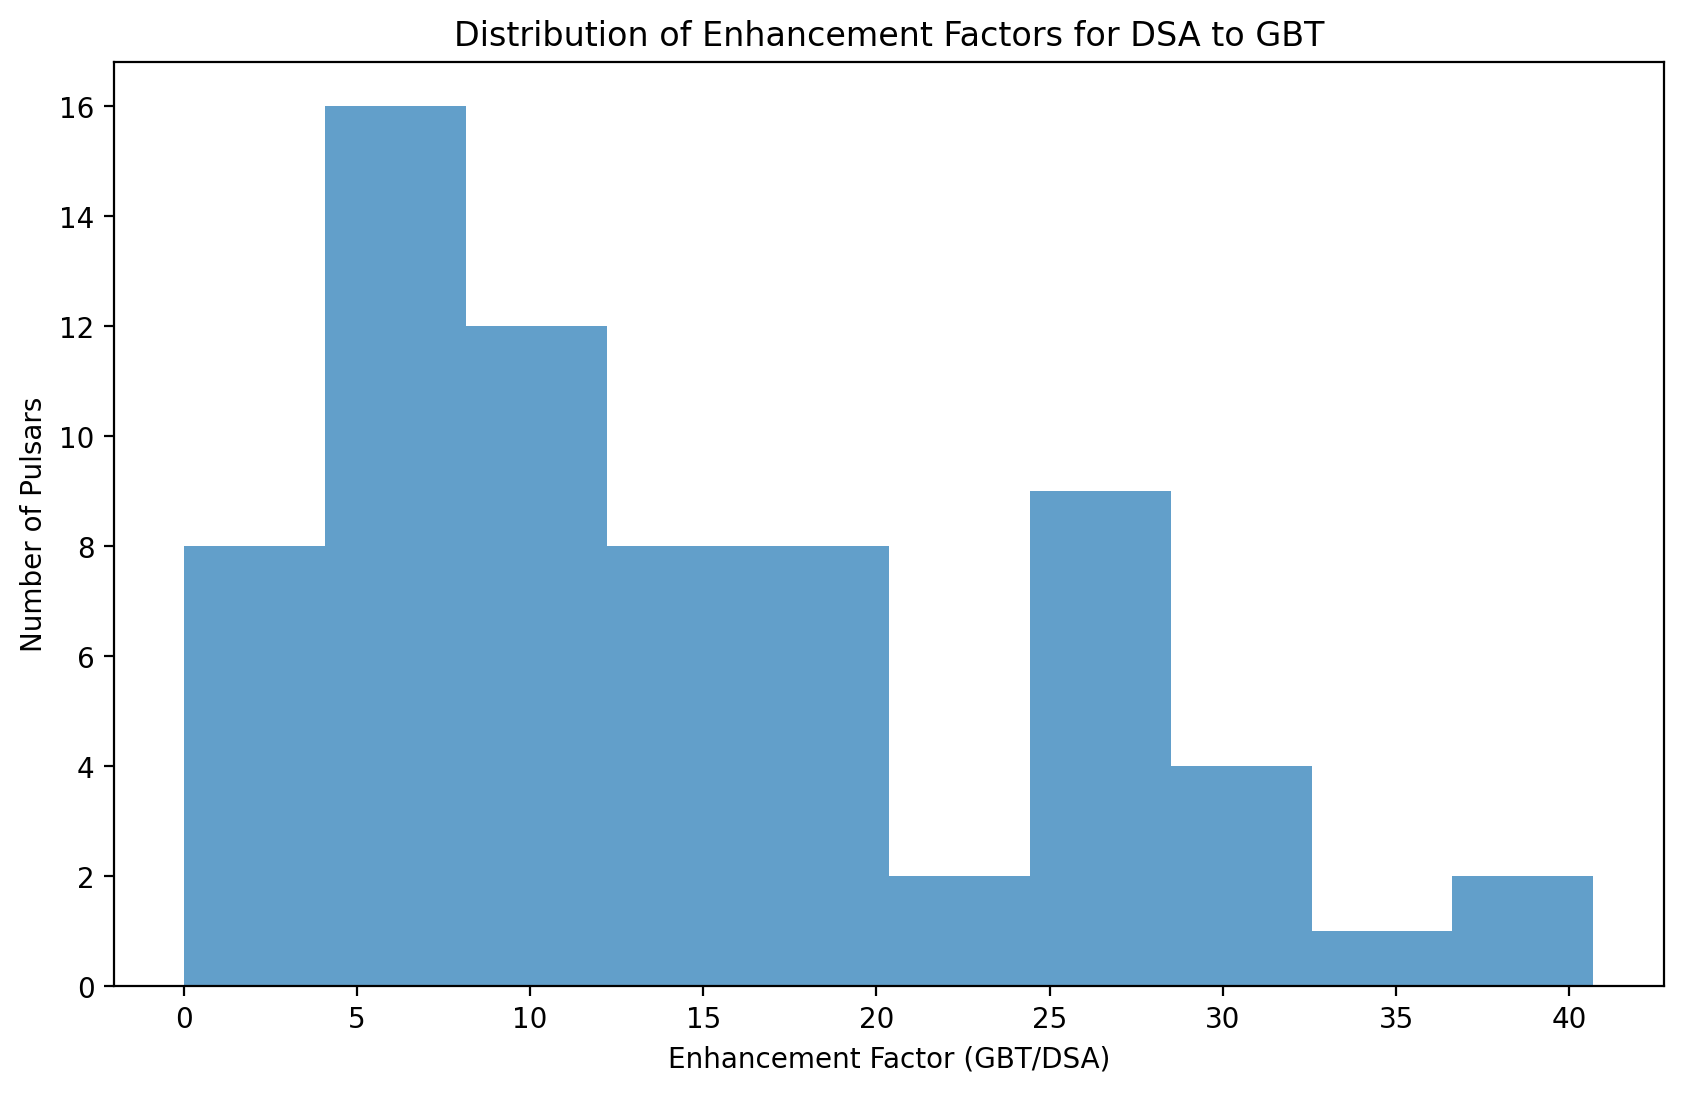

In [16]:
#plot a distribution of the enhancement factors for all pulsars in the dataset
plt.figure(figsize=(10,6))
plt.hist(list(enhancement_factors.values()), bins=10, alpha=0.7)
plt.xlabel('Enhancement Factor (GBT/DSA)')
plt.ylabel('Number of Pulsars')
plt.title('Distribution of Enhancement Factors for DSA to GBT')
plt.show()

In [17]:
#find the pulsar for which the enhancement factor is the highest
max_enhancement_factor = 0
max_enhancement_factor_pulsar = None
for psr_name, enhancement_factor in enhancement_factors.items():
    if enhancement_factor > max_enhancement_factor:
        max_enhancement_factor = enhancement_factor
        max_enhancement_factor_pulsar = psr_name
print('Pulsar with highest enhancement factor:', max_enhancement_factor_pulsar)
print('Highest enhancement factor:', max_enhancement_factor)

Pulsar with highest enhancement factor: J0605+3757
Highest enhancement factor: 40.69662601626017


In [18]:
#mean enhancement factor for all pulsars in the dataset
mean_enhancement_factor = np.mean(list(enhancement_factors.values()))
print('Mean enhancement factor for all pulsars in the dataset:', mean_enhancement_factor)

Mean enhancement factor for all pulsars in the dataset: 14.420054106527623


In [19]:
#lets make a .txt file of per pulsar enhancement factors for DSA to GBT with the first line as titles for the rows
with open('enhancement_factors_dsa_to_gbt.txt', 'w') as f:
    f.write('%Pulsar Name: Enhancement Factor\n')
    for psr_name, enhancement_factor in enhancement_factors.items():
        f.write(f'{psr_name}: {enhancement_factor}\n')

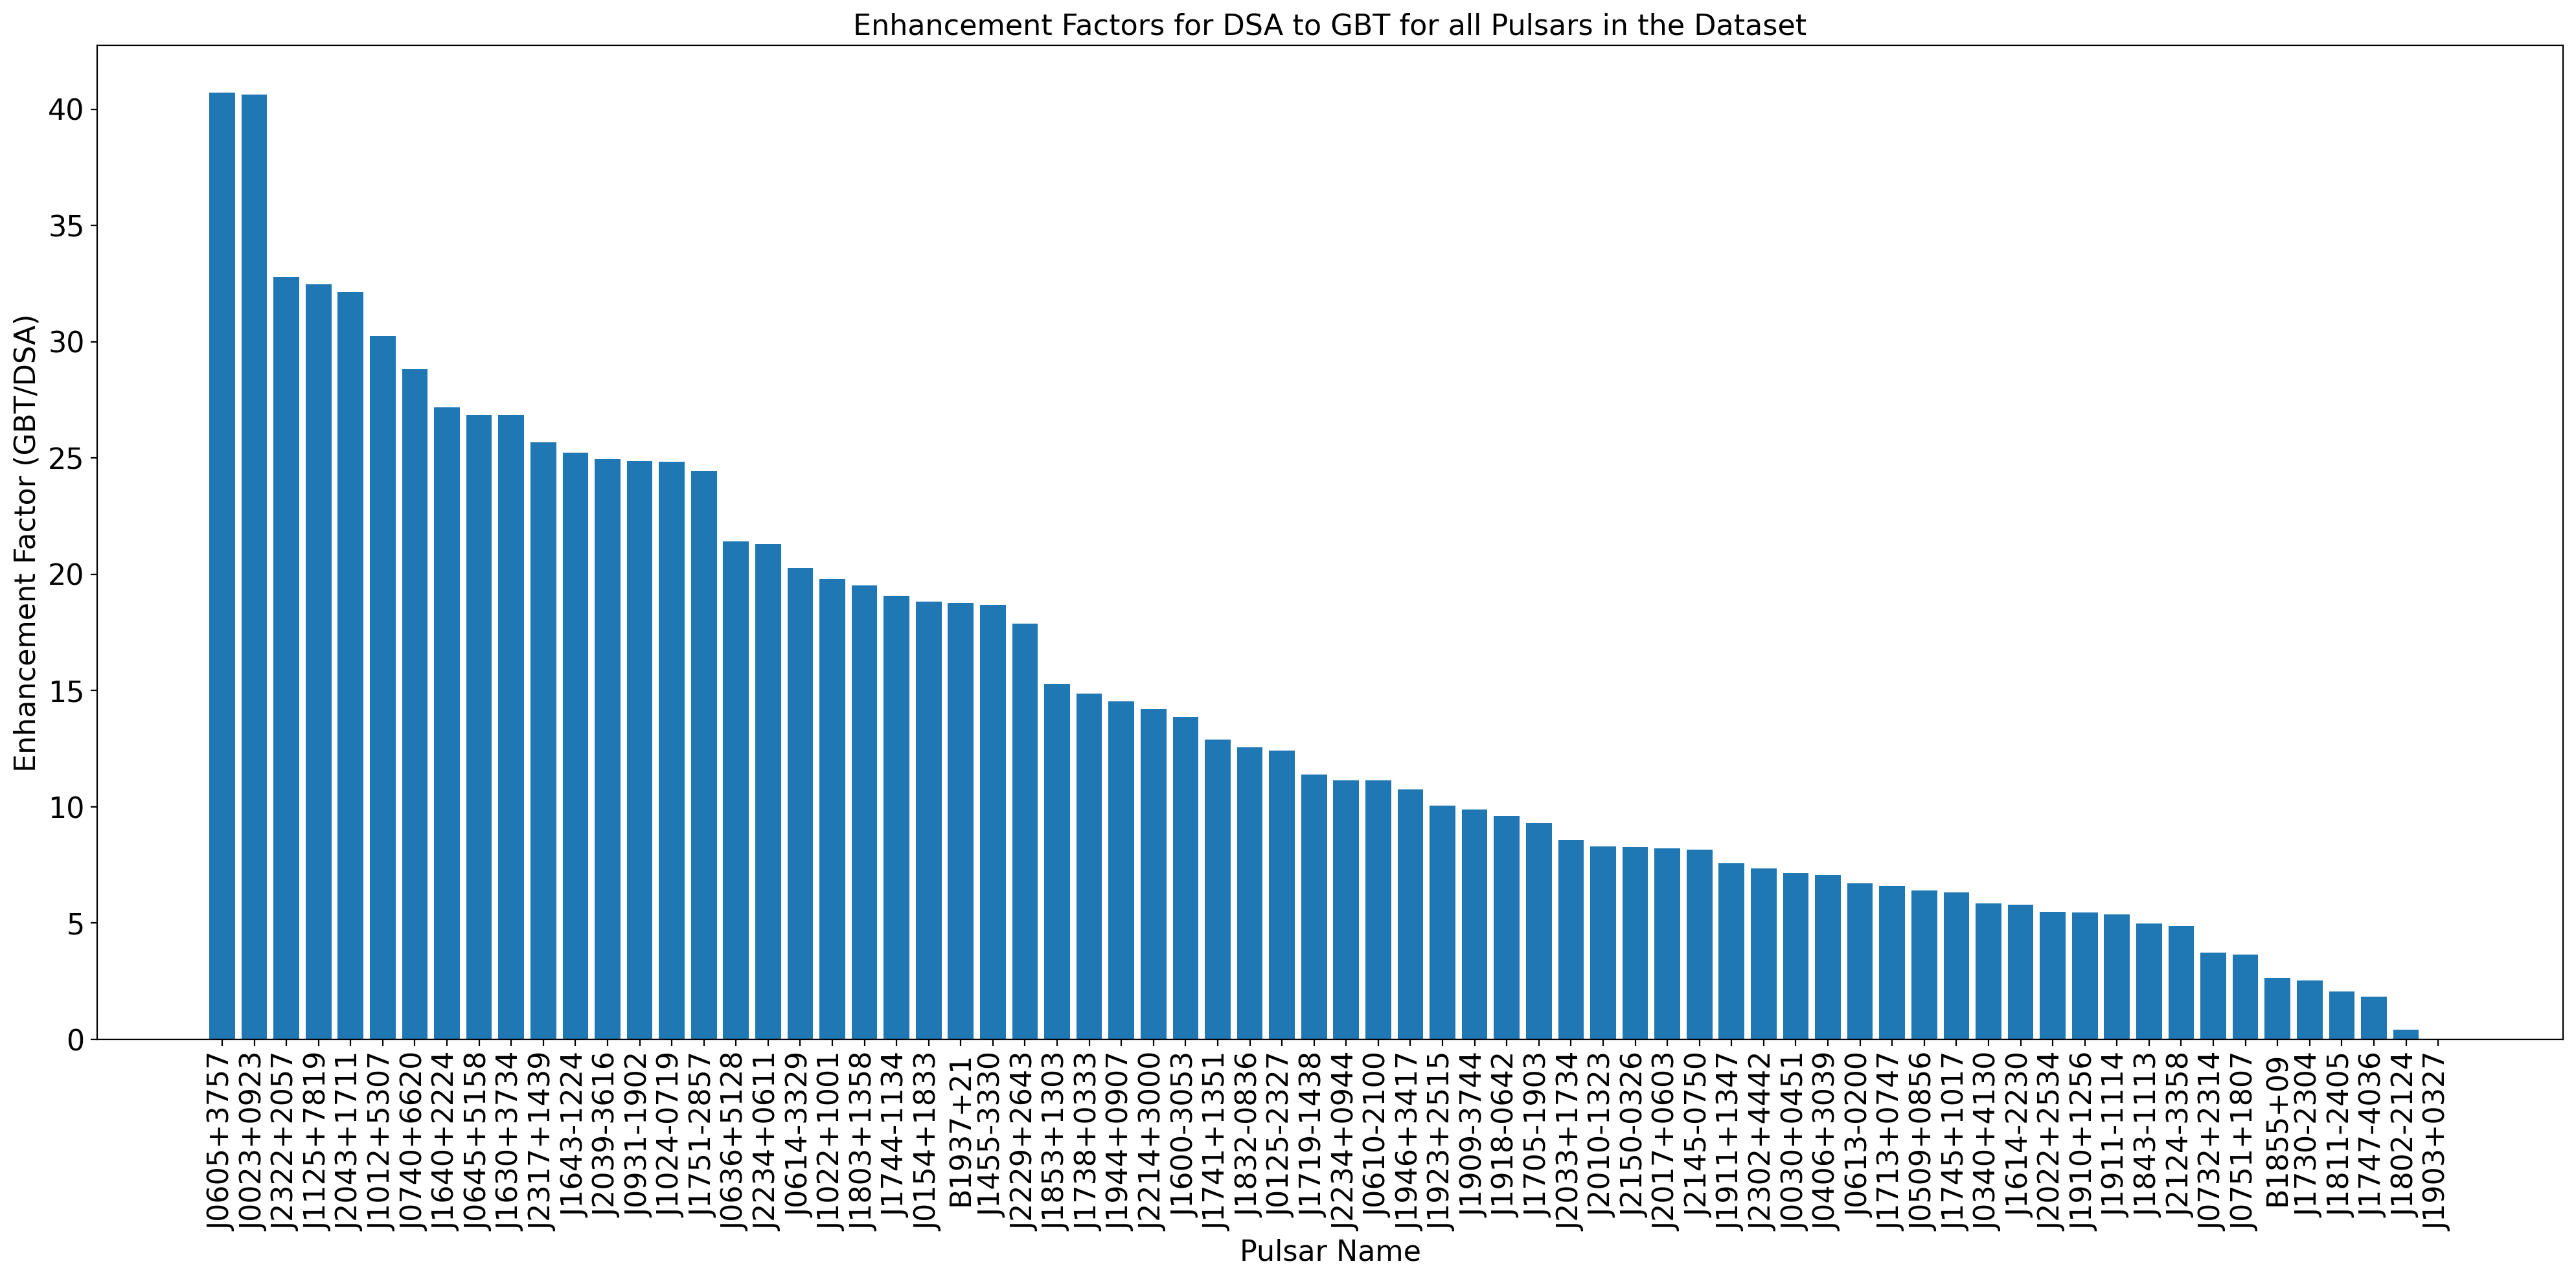

In [20]:
#make a plot of pulsar names vs enhancement factors in decreasing order of enhancement factors
sorted_enhancement_factors = dict(sorted(enhancement_factors.items(), key=lambda item: item[1], reverse=True))
#plt.figure(figsize=20,6))
plt.figure(figsize=(20,10))
plt.bar(sorted_enhancement_factors.keys(), sorted_enhancement_factors.values())
plt.yticks(fontsize=16)
plt.xticks(rotation=90,fontsize=16)
plt.xlabel('Pulsar Name',fontsize=16)
plt.ylabel('Enhancement Factor (GBT/DSA)',fontsize=16)
plt.title('Enhancement Factors for DSA to GBT for all Pulsars in the Dataset',fontsize=16)
plt.tight_layout()
plt.savefig('enhancement_factors_dsa_to_gbt.png')
plt.show()

In [21]:
len(enhancement_factors)

70

In [22]:
#get RA and Dec for all pulsars in the dataset
#make a list of pulsar names and their RA and Dec in degrees
pulsar_coords = {}
for psr in ePsrs:
    pulsar_coords[psr.name] = (psr.theta, psr.phi)

with open('pulsar_coords.txt', 'w') as f:
    f.write('%Pulsar Name: theta, phi\n')
    for psr_name, coords in pulsar_coords.items():
        f.write(f'{psr_name}: {coords[0]}, {coords[1]}\n')

sixty_seven_pulsars = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451',
       'J0340+4130', 'J0406+3039', 'J0437-4715', 'J0509+0856',
       'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200',
       'J0636+5128', 'J0645+5158', 'J0709+0458', 'J0740+6620',
       'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001',
       'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902',
       'J1455-3330', 'J1600-3053', 'J1614-2230', 'J1630+3734',
       'J1640+2224', 'J1643-1224', 'J1705-1903', 'J1713+0747',
       'J1719-1438', 'J1730-2304', 'J1738+0333', 'J1741+1351',
       'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857',
       'J1802-2124', 'J1811-2405', 'J1832-0836', 'J1843-1113',
       'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256',
       'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907',
       'J1946+3417', 'J2010-1323', 'J2017+0603', 'J2033+1734',
       'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000',
       'J2229+2643', 'J2234+0611', 'J2234+0944', 'J2302+4442',
       'J2317+1439', 'J2322+2057']


#make a list of pulsars in the dataset that are not in the 67 pulsars
pulsars_not_in_67 = [psr.name for psr in ePsrs if psr.name not in sixty_seven_pulsars]
with open('thirteen_pulsars_skypos.txt', 'w') as f:
    f.write('%Pulsar Name: theta, phi\n')
    for psr_name in pulsars_not_in_67:
        coords = pulsar_coords.get(psr_name, (None, None))
        f.write(f'{psr_name}: {coords[0]}, {coords[1]}\n')


In [23]:
#70 pulsars had enhancement factors calculated, 10 pulsars did not
#lets randomly draw enhancement factors for the 10 pulsars that did not have enhancement factors calculated from the 70 pulsars that did have enhancement factors calculated
import random
random.seed(42)

#distribution of enhancement factors for the 70 pulsars that had enhancement factors calculated
enhancement_factors_values = list(enhancement_factors.values())

#draw 10 random enhancement factors from the distribution of enhancement factors for the 70 pulsars that had enhancement factors calculated
random_enhancement_factors = random.sample(enhancement_factors_values, 10)

#assign the randomly drawn enhancement factors to the 10 pulsars that did not have enhancement factors calculated
for psr, ef in zip(pulsars_without_dsa_gbt, random_enhancement_factors):
    enhancement_factors[psr] = ef

#write these 10 pulsars and their randomly assigned enhancement factors to a .txt file
with open('enhancement_factors_dsa_to_gbt_10_extra_pulsars.txt', 'w') as f:
    f.write('%Pulsar Name: Enhancement Factor\n')
    for psr, ef in zip(pulsars_without_dsa_gbt, random_enhancement_factors):
        f.write(f'{psr}: {ef}\n')

In [44]:
#make a dictionary of the 13 pulsars and their theta phi and avg gbt uncertainty 

thirteen_pulsars_dict = {}
for psr in pulsars_not_in_67:
    ePsr = next((p for p in ePsrs if p.name == psr), None)
    print('Processing pulsar:', psr)
    print('ePsr name:', ePsr.name)
    coords = pulsar_coords.get(psr, (None, None))
    #take the average of the GBT TOA uncertainties for the pulsar
    mask = ePsr.telescope == 'gbt'
    avg_toa_uncertainty_gbt = np.mean(ePsr.toaerrs[mask])
    print('Average GBT TOA uncertainty for pulsar {}: {}'.format(psr, avg_toa_uncertainty_gbt))
    thirteen_pulsars_dict[psr] = {'theta': float(coords[0]), 'phi': float(coords[1]), 'rms': float(avg_toa_uncertainty_gbt)}

Processing pulsar: J0102+4839
ePsr name: J0102+4839
Average GBT TOA uncertainty for pulsar J0102+4839: nan
Processing pulsar: J0125-2327
ePsr name: J0125-2327
Average GBT TOA uncertainty for pulsar J0125-2327: 9.428699551569506e-07
Processing pulsar: J0154+1833
ePsr name: J0154+1833
Average GBT TOA uncertainty for pulsar J0154+1833: 1.2053548387096772e-06
Processing pulsar: J0218+4232
ePsr name: J0218+4232
Average GBT TOA uncertainty for pulsar J0218+4232: nan
Processing pulsar: J0614-3329
ePsr name: J0614-3329
Average GBT TOA uncertainty for pulsar J0614-3329: 1.4197117647058824e-06
Processing pulsar: J0621+2514
ePsr name: J0621+2514
Average GBT TOA uncertainty for pulsar J0621+2514: nan
Processing pulsar: J0732+2314
ePsr name: J0732+2314
Average GBT TOA uncertainty for pulsar J0732+2314: 2.460028571428572e-06
Processing pulsar: J0751+1807
ePsr name: J0751+1807
Average GBT TOA uncertainty for pulsar J0751+1807: 5.490416666666666e-07
Processing pulsar: J1803+1358
ePsr name: J1803+1358


In [46]:
thirteen_pulsars_dict

{'J0102+4839': {'theta': 0.721486400100311,
  'phi': 0.27421030533870755,
  'rms': nan},
 'J0125-2327': {'theta': 1.980115351688903,
  'phi': 0.3709608670687861,
  'rms': 9.428699551569506e-07},
 'J0154+1833': {'theta': 1.2467917399497854,
  'phi': 0.5001012309879045,
  'rms': 1.2053548387096772e-06},
 'J0218+4232': {'theta': 0.8283654291301162,
  'phi': 0.6026012279083033,
  'rms': nan},
 'J0614-3329': {'theta': 2.1554529755294656,
  'phi': 1.6326353872446615,
  'rms': 1.4197117647058824e-06},
 'J0621+2514': {'theta': 1.130374145942607,
  'phi': 1.6632154889855533,
  'rms': nan},
 'J0732+2314': {'theta': 1.1650355311819671,
  'phi': 1.9749501953523494,
  'rms': 2.460028571428572e-06},
 'J0751+1807': {'theta': 1.25441487704485,
  'phi': 2.0557908486064314,
  'rms': 5.490416666666666e-07},
 'J1803+1358': {'theta': 1.3269332286752422,
  'phi': 4.726565942196955,
  'rms': 3.281224137931034e-06},
 'J1911-1114': {'theta': 1.7669647961678763,
  'phi': 5.025767941135255,
  'rms': 1.6728051948

In [47]:
#draw three values from the distibution of avg gbt uncertainties for the 70 pulsars
len(all_pulsar_avg_toa_uncertainties_gbt)

#skip nans in this list
all_pulsar_avg_toa_uncertainties_gbt_no_nan = [x for x in all_pulsar_avg_toa_uncertainties_gbt if not np.isnan(x)]
print(len(all_pulsar_avg_toa_uncertainties_gbt_no_nan))


71


(array([118969.87691627, 356909.6307488 , 654334.32303947, 475879.50766507,
        356909.6307488 , 297424.69229067, 356909.6307488 , 237939.75383253,
             0.        , 237939.75383253, 118969.87691627,  59484.93845813,
        356909.6307488 , 118969.87691627, 118969.87691627,      0.        ,
             0.        , 178454.8153744 ,      0.        , 178454.8153744 ]),
 array([1.48108322e-07, 3.84882662e-07, 6.21657002e-07, 8.58431342e-07,
        1.09520568e-06, 1.33198002e-06, 1.56875436e-06, 1.80552870e-06,
        2.04230304e-06, 2.27907738e-06, 2.51585172e-06, 2.75262606e-06,
        2.98940040e-06, 3.22617474e-06, 3.46294908e-06, 3.69972342e-06,
        3.93649776e-06, 4.17327210e-06, 4.41004644e-06, 4.64682078e-06,
        4.88359512e-06]),
 <BarContainer object of 20 artists>)

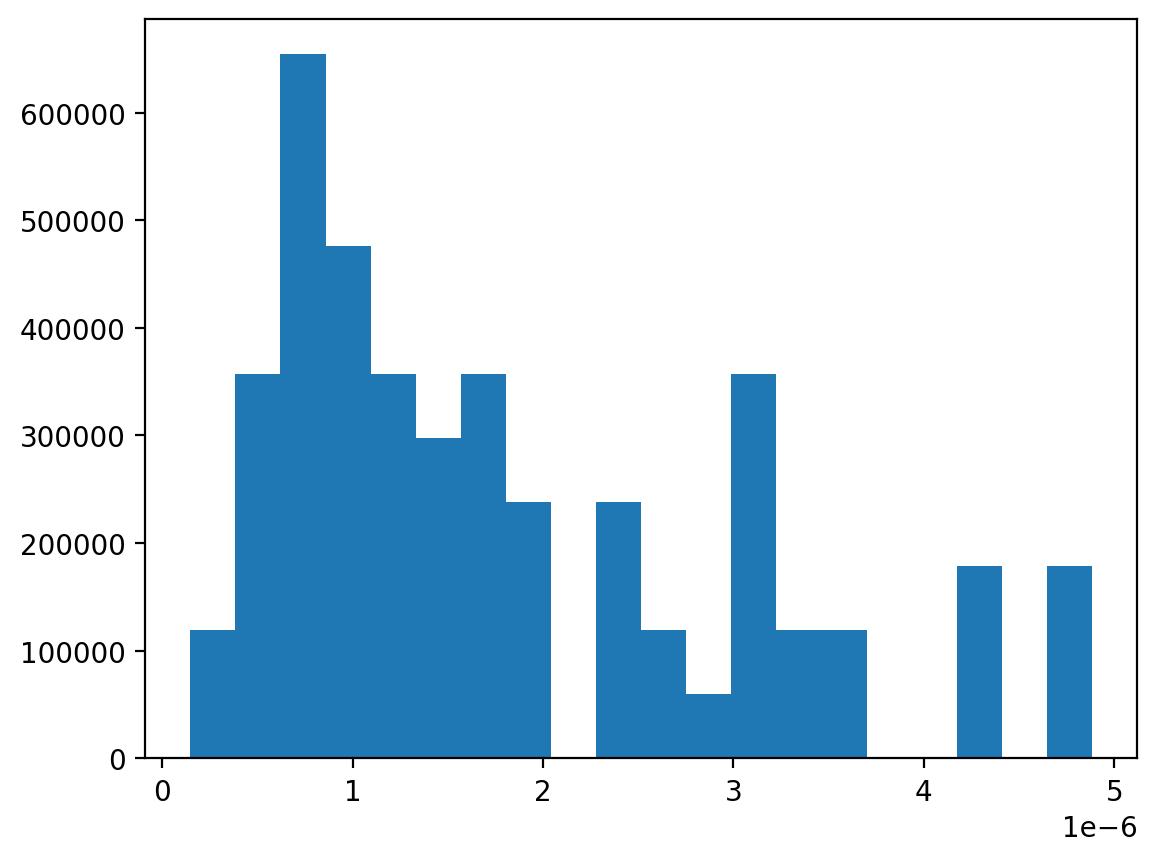

In [48]:
#get distribution of the avg gbt uncertainties for the 71 pulsars to draw from
dist_gbt_uncertainties = np.histogram(all_pulsar_avg_toa_uncertainties_gbt_no_nan, bins=20, density=True)
plt.hist(all_pulsar_avg_toa_uncertainties_gbt_no_nan, bins=20, density=True)


In [49]:
#lets draw 3 random values from the distribution of avg gbt uncertainties
from scipy.stats import rv_histogram

gbt_uncertainty_dist = rv_histogram(dist_gbt_uncertainties)
random_3 = gbt_uncertainty_dist.rvs(size=3, random_state=42)
print(random_3)

[1.08314050e-06 4.37064054e-06 2.51416884e-06]


In [54]:
#add these 3 random values to the 13 pulsars dict for the 3 pulsars for which currently the GBT uncertainties are nan
nan_gbt_pulsars = [psr for psr, vals in thirteen_pulsars_dict.items() if np.isnan(vals['rms'])]
print('Pulsars with nan GBT uncertainty:', nan_gbt_pulsars)

for psr, random_val in zip(nan_gbt_pulsars, random_3):
    thirteen_pulsars_dict[psr]['rms'] = float(random_val)

thirteen_pulsars_dict

Pulsars with nan GBT uncertainty: ['J0102+4839', 'J0218+4232', 'J0621+2514']


{'J0102+4839': {'theta': 0.721486400100311,
  'phi': 0.27421030533870755,
  'rms': 1.0831405035631714e-06},
 'J0125-2327': {'theta': 1.980115351688903,
  'phi': 0.3709608670687861,
  'rms': 9.428699551569506e-07},
 'J0154+1833': {'theta': 1.2467917399497854,
  'phi': 0.5001012309879045,
  'rms': 1.2053548387096772e-06},
 'J0218+4232': {'theta': 0.8283654291301162,
  'phi': 0.6026012279083033,
  'rms': 4.370640542805826e-06},
 'J0614-3329': {'theta': 2.1554529755294656,
  'phi': 1.6326353872446615,
  'rms': 1.4197117647058824e-06},
 'J0621+2514': {'theta': 1.130374145942607,
  'phi': 1.6632154889855533,
  'rms': 2.5141688407392176e-06},
 'J0732+2314': {'theta': 1.1650355311819671,
  'phi': 1.9749501953523494,
  'rms': 2.460028571428572e-06},
 'J0751+1807': {'theta': 1.25441487704485,
  'phi': 2.0557908486064314,
  'rms': 5.490416666666666e-07},
 'J1803+1358': {'theta': 1.3269332286752422,
  'phi': 4.726565942196955,
  'rms': 3.281224137931034e-06},
 'J1911-1114': {'theta': 1.76696479616

In [55]:
thirteen_pulsars_dict

{'J0102+4839': {'theta': 0.721486400100311,
  'phi': 0.27421030533870755,
  'rms': 1.0831405035631714e-06},
 'J0125-2327': {'theta': 1.980115351688903,
  'phi': 0.3709608670687861,
  'rms': 9.428699551569506e-07},
 'J0154+1833': {'theta': 1.2467917399497854,
  'phi': 0.5001012309879045,
  'rms': 1.2053548387096772e-06},
 'J0218+4232': {'theta': 0.8283654291301162,
  'phi': 0.6026012279083033,
  'rms': 4.370640542805826e-06},
 'J0614-3329': {'theta': 2.1554529755294656,
  'phi': 1.6326353872446615,
  'rms': 1.4197117647058824e-06},
 'J0621+2514': {'theta': 1.130374145942607,
  'phi': 1.6632154889855533,
  'rms': 2.5141688407392176e-06},
 'J0732+2314': {'theta': 1.1650355311819671,
  'phi': 1.9749501953523494,
  'rms': 2.460028571428572e-06},
 'J0751+1807': {'theta': 1.25441487704485,
  'phi': 2.0557908486064314,
  'rms': 5.490416666666666e-07},
 'J1803+1358': {'theta': 1.3269332286752422,
  'phi': 4.726565942196955,
  'rms': 3.281224137931034e-06},
 'J1911-1114': {'theta': 1.76696479616